In [1]:
#!/usr/bin/env python
from __future__ import annotations

import os
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
from sqlalchemy import create_engine, text

import verde as vd
from scipy.ndimage import gaussian_filter

# ----------------------------------------------------------------------
# CONFIGURAÇÕES
# ----------------------------------------------------------------------
PG_USER = "postgres"
PG_PASS = "postgres"
PG_HOST = "localhost"
PG_PORT = "5432"
PG_DB   = "geologia"

PG_CONN_STR = (
    f"postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)

# Diretório onde estão S2_stack e ASTER_GS
RASTER_DIR = "./recortes_orbitais"

# Folha alvo
FOLHA_CODIGO = "SB21_ZA_II2_NW"

# IDs usados na etapa GS anterior
S2_ID    = "S2B_MSIL2A_20230703T140709_R110_T21MWP_20241013T181213"
ASTER_ID = "AST_L1T_00307292004141220_20150505110335"

# Variáveis gama (colunas da view) a usar como "geo_lj"
GAMMA_VARS = ["ctcor_np", "kperc_np", "eu_np", "eth_np"]

# Sigma do filtro Gaussiano para decomposição (em pixels)
SIGMA_LAPLACE = 5.0

# Número mínimo de pixels válidos para calcular correlação/OLS
MIN_PIXELS = 1000

# Arquivos de saída
OUT_GAMMA_INTERP = os.path.join(
    RASTER_DIR, f"{FOLHA_CODIGO}_gamma_interp_10m.tif"
)
OUT_GAMMA_LF = os.path.join(
    RASTER_DIR, f"{FOLHA_CODIGO}_gamma_lowfreq_10m.tif"
)
OUT_GAMMA_FUSED = os.path.join(
    RASTER_DIR, f"{FOLHA_CODIGO}_gamma_fused_laplacian_10m.tif"
)


# ----------------------------------------------------------------------
# AUXILIARES
# ----------------------------------------------------------------------
def get_engine():
    print("[DB] Criando engine PostgreSQL...")
    return create_engine(PG_CONN_STR)


def load_supercube(folha_codigo: str) -> xr.DataArray:
    """
    Carrega o super-cubo S2_stack + ASTER_GS
    (mesma lógica usada no build_dataset_pixels).
    """
    s2_stack_path = os.path.join(
        RASTER_DIR,
        f"{folha_codigo}_S2_{S2_ID}_stack.tif",
    )
    print(f"[LOAD] Lendo S2_stack em: {s2_stack_path}")
    if not os.path.exists(s2_stack_path):
        raise FileNotFoundError(s2_stack_path)

    s2_stack = rioxarray.open_rasterio(s2_stack_path, masked=True).astype("float32")
    print(f"[LOAD] S2_stack shape = {s2_stack.shape}")

    aster_gs_path = os.path.join(
        RASTER_DIR,
        f"{folha_codigo}_ASTER_{ASTER_ID}_VNIR_SWIR_GS_10m.tif",
    )
    print(f"[LOAD] Lendo ASTER_GS em: {aster_gs_path}")
    if not os.path.exists(aster_gs_path):
        raise FileNotFoundError(aster_gs_path)

    aster_gs = rioxarray.open_rasterio(aster_gs_path, masked=True).astype("float32")
    print(f"[LOAD] ASTER_GS shape (antes reproject) = {aster_gs.shape}")

    aster_gs = aster_gs.rio.reproject_match(s2_stack)
    print(f"[LOAD] ASTER_GS shape (após reproject) = {aster_gs.shape}")

    s2_names    = [str(b) for b in s2_stack.band.values]
    aster_names = [str(b) for b in aster_gs.band.values]
    super_names = s2_names + aster_names

    super_cube = xr.concat([s2_stack, aster_gs], dim="band")
    super_cube = super_cube.assign_coords(band=("band", super_names))

    super_cube.rio.write_crs(s2_stack.rio.crs, inplace=True)
    super_cube.rio.write_transform(s2_stack.rio.transform(), inplace=True)

    print(f"[LOAD] Super-cubo final shape = {super_cube.shape}")
    return super_cube


def load_gamma_points_for_folha(
    folha_codigo: str,
    engine,
) -> pd.DataFrame:
    """
    Busca dados gama (ctcor_np, kperc_np, eu_np, eth_np) dentro da folha.

    Usa interseção entre v.geom (Point, 4326) e carto.folhas_cartograficas.geom.
    Supondo que folhas_cartograficas.geom esteja em algum CRS projetado,
    fazemos ST_Transform para 4326 na cláusula ST_Intersects.
    """
    print(f"[DB] Buscando pontos gama para folha '{folha_codigo}'...")
    sql = text(
        """
        SELECT
            v.ctcor_np,
            v.kperc_np,
            v.eu_np,
            v.eth_np,
            v.x,
            v.y
        FROM geof.v_gamma_1082_corr_mean_total_med v
        JOIN carto.folhas_cartograficas f
          ON f.codigo = :codigo
        WHERE ST_Intersects(
            v.geom,
            ST_Transform(f.geom, 4326)
        );
        """
    )

    with engine.begin() as conn:
        df = pd.read_sql(sql, conn, params={"codigo": folha_codigo})

    if df.empty:
        raise RuntimeError(f"Nenhum dado gama encontrado na folha {folha_codigo}.")

    print(f"[DB] Pontos gama retornados: {len(df)}")
    print(f"[DB] Colunas gama disponíveis: {df.columns.tolist()}")
    return df


def gaussian_filter_nan(arr: np.ndarray, sigma: float) -> np.ndarray:
    """
    Filtro Gaussiano que respeita NaN: usa convolução ponderada.
    """
    arr = np.asarray(arr, dtype="float32")
    mask = np.isfinite(arr)

    arr0 = np.where(mask, arr, 0.0)
    weight = gaussian_filter(mask.astype("float32"), sigma=sigma)
    smooth = gaussian_filter(arr0, sigma=sigma)

    with np.errstate(invalid="ignore", divide="ignore"):
        smooth = smooth / weight
    smooth[weight == 0] = np.nan

    return smooth.astype("float32")


def interpolate_gamma_to_grid(
    df_gamma: pd.DataFrame,
    ms_da: xr.DataArray,
    gamma_vars: List[str],
) -> xr.DataArray:
    """
    Interpola cada variável gama (ctcor_np, kperc_np, etc) para a grade do super-cubo,
    usando vd.Cubic (mais rápido que Spline para este caso).
    """
    print("[INTERP] Iniciando interpolação gama para grade do super-cubo (vd.Cubic)...")

    x = df_gamma["x"].values.astype("float64")
    y = df_gamma["y"].values.astype("float64")
    coords = (x, y)

    print(f"[INTERP] Número de pontos gama = {len(x)}")
    print(f"[INTERP] Extensão X: [{x.min():.1f}, {x.max():.1f}]")
    print(f"[INTERP] Extensão Y: [{y.min():.1f}, {y.max():.1f}]")

    x_grid = ms_da.x.values
    y_grid = ms_da.y.values
    XX, YY = np.meshgrid(x_grid, y_grid)
    coords_grid = (XX.ravel(), YY.ravel())

    print(f"[INTERP] Grade alvo: nx={len(x_grid)}, ny={len(y_grid)}, Npix={XX.size}")

    gamma_grids = []
    for var in gamma_vars:
        print(f"[INTERP]  -> Interpolando variável '{var}' com vd.Cubic()...")
        data = df_gamma[var].values.astype("float64")

        # vd.Cubic como gridder + predictor
        cubic = vd.Cubic().fit(coords, data)
        pred = cubic.predict(coords_grid)

        arr = pred.reshape(len(y_grid), len(x_grid)).astype("float32")
        gamma_grids.append(arr)

        print(
            f"[INTERP]     '{var}' concluída: "
            f"min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}"
        )

    gamma_arr = np.stack(gamma_grids, axis=0)  # (n_gamma, ny, nx)

    gamma_da = xr.DataArray(
        data=gamma_arr,
        dims=("band", "y", "x"),
        coords={"band": gamma_vars, "y": y_grid, "x": x_grid},
        attrs={"description": "Gama interpolado (vd.Cubic) na grade do super-cubo"},
    )
    gamma_da.rio.write_crs(ms_da.rio.crs, inplace=True)
    gamma_da.rio.write_transform(ms_da.rio.transform(), inplace=True)

    print("[INTERP] Interpolação gama concluída.")
    return gamma_da


def laplacian_decompose_ms(
    ms_da: xr.DataArray,
    sigma: float,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Decomposição tipo Laplacian:

    MS_Li = passa-baixa gaussiano
    MS_Hi = MS - MS_Li
    """
    ms = ms_da.values  # (n_ms, ny, nx)
    n_ms, ny, nx = ms.shape

    print(f"[LAPLACE] Decompondo {n_ms} bandas MS com sigma={sigma}...")
    ms_low  = np.empty_like(ms, dtype="float32")
    ms_high = np.empty_like(ms, dtype="float32")

    band_names = [str(b) for b in ms_da.band.values]

    for i in range(n_ms):
        print(f"[LAPLACE]  -> banda {i} ('{band_names[i]}'), shape=({ny},{nx})")
        band = ms[i]
        low  = gaussian_filter_nan(band, sigma)
        high = band - low
        ms_low[i]  = low
        ms_high[i] = high

    print("[LAPLACE] Decomposição MS (low/high) finalizada.")
    return ms_low, ms_high


def lowfreq_gamma(
    gamma_da: xr.DataArray,
    sigma: float,
) -> np.ndarray:
    """
    Aplica passa-baixa gaussiano em cada camada gama para obter geo_lj.
    """
    g = gamma_da.values  # (n_gamma, ny, nx)
    n_gamma, ny, nx = g.shape
    print(f"[LOWFREQ] Calculando low-frequency para {n_gamma} variáveis gama (sigma={sigma})...")

    g_low = np.empty_like(g, dtype="float32")
    gamma_names = [str(b) for b in gamma_da.band.values]

    for j, name in enumerate(gamma_names):
        print(f"[LOWFREQ]  -> variável '{name}'")
        g_low[j] = gaussian_filter_nan(g[j], sigma)

    print("[LOWFREQ] Low-frequency gamma concluído.")
    return g_low


def fuse_gamma_laplacian(
    ms_da: xr.DataArray,
    ms_low: np.ndarray,
    ms_high: np.ndarray,
    gamma_da: xr.DataArray,
    gamma_low: np.ndarray,
    min_pixels: int = 1000,
) -> Tuple[xr.DataArray, xr.DataArray, List[Dict]]:
    """
    Implementa a fusão conforme o esquema:

      geo_lj = lowfreq(gamma_j)
      MS_Li, MS_Hi = decomp Laplacian de cada banda MS
      geo_lj ~ f_ij * MS_Li  (estima f_ij via regressão; escolhe banda i com |corr| máximo)
      geo_hj = f_j * MS_H(i*)
      geo_fj = geo_lj + geo_hj

    Retorna:
      gamma_low_da : low-frequency gamma (geo_lj)
      gamma_fused_da : geo_fj (gamma fundido)
      info : lista com metadados (var, idx_ms, band_name, slope, corr)
    """
    ms = ms_da.values           # (n_ms, ny, nx)
    gamma = gamma_da.values     # (n_gamma, ny, nx)
    n_ms, ny, nx = ms.shape
    n_gamma = gamma.shape[0]

    ms_band_names = [str(b) for b in ms_da.band.values]
    gamma_names   = [str(b) for b in gamma_da.band.values]

    print("[FUSE] Iniciando fusão Laplacian gama + MS...")
    print(f"[FUSE] n_ms={n_ms}, n_gamma={n_gamma}, ny={ny}, nx={nx}")

    # Máscara onde existe MS válido em pelo menos uma banda
    ms_valid = np.isfinite(ms).any(axis=0)  # (ny, nx)

    # Aplicar máscara à lowfreq gamma
    gamma_low_masked = np.where(
        ms_valid[None, :, :],
        gamma_low,
        np.nan,
    )

    gamma_fused = np.empty_like(gamma_low_masked, dtype="float32")

    info: List[Dict] = []

    for j, gname in enumerate(gamma_names):
        print(f"[FUSE] Variável gama '{gname}': buscando banda MS com |corr| máximo...")
        y = gamma_low_masked[j]  # geo_lj
        # máscara de válidos em geo_lj
        mask_y = np.isfinite(y) & ms_valid

        best_abs_corr = -np.inf
        best_idx_ms   = None
        best_slope    = 0.0
        best_corr     = 0.0

        for i in range(n_ms):
            x = ms_low[i]   # MS_Li
            mask = mask_y & np.isfinite(x)
            if mask.sum() < min_pixels:
                continue

            x_flat = x[mask].ravel()
            y_flat = y[mask].ravel()

            r = np.corrcoef(x_flat, y_flat)[0, 1]
            if np.isnan(r):
                continue

            slope = np.polyfit(x_flat, y_flat, 1)[0]

            if np.abs(r) > best_abs_corr:
                best_abs_corr = np.abs(r)
                best_corr     = r
                best_idx_ms   = i
                best_slope    = slope

        if best_idx_ms is None:
            print(f"[FUSE][WARN] Nenhuma banda MS adequada para '{gname}'; usando somente lowfreq.")
            gamma_fused[j] = gamma_low_masked[j]
            info.append(
                {
                    "gamma_var": gname,
                    "ms_idx": None,
                    "ms_band": None,
                    "slope": 0.0,
                    "corr": 0.0,
                }
            )
            continue

        print(
            f"[FUSE]  -> '{gname}': banda MS escolhida = '{ms_band_names[best_idx_ms]}' "
            f"(idx={best_idx_ms}), slope={best_slope:.4f}, corr={best_corr:.4f}"
        )

        # geo_h = f_j * MS_H(i*)
        geo_h = best_slope * ms_high[best_idx_ms]

        # geo_f = geo_lj + geo_h
        geo_f = gamma_low_masked[j] + geo_h
        geo_f[~ms_valid] = np.nan  # fora da área MS, mantemos NaN

        gamma_fused[j] = geo_f

        info.append(
            {
                "gamma_var": gname,
                "ms_idx": int(best_idx_ms),
                "ms_band": ms_band_names[best_idx_ms],
                "slope": float(best_slope),
                "corr": float(best_corr),
            }
        )

    gamma_low_da = xr.DataArray(
        data=gamma_low_masked,
        dims=("band", "y", "x"),
        coords={"band": gamma_names, "y": ms_da.y, "x": ms_da.x},
        attrs={"description": "Gamma low-frequency (geo_lj) após filtro gaussiano"},
    )
    gamma_low_da.rio.write_crs(ms_da.rio.crs, inplace=True)
    gamma_low_da.rio.write_transform(ms_da.rio.transform(), inplace=True)

    gamma_fused_da = xr.DataArray(
        data=gamma_fused,
        dims=("band", "y", "x"),
        coords={"band": gamma_names, "y": ms_da.y, "x": ms_da.x},
        attrs={"description": "Gamma fundido com MS (método Laplacian Ding et al.)"},
    )
    gamma_fused_da.rio.write_crs(ms_da.rio.crs, inplace=True)
    gamma_fused_da.rio.write_transform(ms_da.rio.transform(), inplace=True)

    print("[FUSE] Fusão Laplacian concluída.")
    return gamma_low_da, gamma_fused_da, info


# ----------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------
def main():
    print("=" * 80)
    print(f"[FUSÃO LAPLACIAN] Folha alvo: {FOLHA_CODIGO}")
    print("=" * 80)

    engine = get_engine()

    # 1) Super-cubo MS (S2 + ASTER_GS) já recortado para a folha
    print("[STEP] Carregando super-cubo (S2 + ASTER_GS)...")
    ms_da = load_supercube(FOLHA_CODIGO)
    print(f"[INFO] Super-cubo MS shape = {ms_da.shape}")
    print(f"[INFO] Bandas MS = {list(ms_da.band.values)}")
    print(f"[INFO] CRS MS   = {ms_da.rio.crs}")

    # 2) Pontos gama dentro da folha
    print("[STEP] Buscando pontos gama no banco...")
    df_gamma = load_gamma_points_for_folha(FOLHA_CODIGO, engine)
    print(f"[INFO] Pontos gama dentro da folha: {len(df_gamma)}")

    # 3) Interpolar gama para grade do MS
    print("[STEP] Interpolando variáveis gama para a grade MS (vd.Cubic)...")
    gamma_da = interpolate_gamma_to_grid(
        df_gamma=df_gamma,
        ms_da=ms_da,
        gamma_vars=GAMMA_VARS,
    )
    print(f"[INFO] Gamma interpolado shape = {gamma_da.shape}")
    print(f"[INFO] Gamma bands = {list(gamma_da.band.values)}")

    # 4) Decomposição Laplacian dos MS
    print("[STEP] Decomposição Laplacian das bandas MS...")
    ms_low, ms_high = laplacian_decompose_ms(
        ms_da=ms_da,
        sigma=SIGMA_LAPLACE,
    )

    # 5) Low-frequency gamma (geo_lj)
    print("[STEP] Calculando low-frequency (geo_lj) para gama...")
    gamma_low = lowfreq_gamma(
        gamma_da=gamma_da,
        sigma=SIGMA_LAPLACE,
    )

    # 6) Fusão geo_f = geo_lj + f_j * MS_H(i*)
    print("[STEP] Executando fusão geo_f = geo_lj + f_j * MS_H(i*)...")
    gamma_low_da, gamma_fused_da, info = fuse_gamma_laplacian(
        ms_da=ms_da,
        ms_low=ms_low,
        ms_high=ms_high,
        gamma_da=gamma_da,
        gamma_low=gamma_low,
        min_pixels=MIN_PIXELS,
    )

    print("\n[INFO] Bandas MS escolhidas por variável gama:")
    for item in info:
        print(
            f"  {item['gamma_var']}: "
            f"MS_band={item['ms_band']} (idx={item['ms_idx']}), "
            f"slope={item['slope']:.4f}, corr={item['corr']:.4f}"
        )

    # 7) Salvar resultados em GeoTIFF
    print("[STEP] Salvando rasters de saída...")
    gamma_da.rio.to_raster(OUT_GAMMA_INTERP)
    print(f"[OUTPUT] Gamma interpolado salvo em: {OUT_GAMMA_INTERP}")

    gamma_low_da.rio.to_raster(OUT_GAMMA_LF)
    print(f"[OUTPUT] Gamma low-frequency salvo em: {OUT_GAMMA_LF}")

    gamma_fused_da.rio.to_raster(OUT_GAMMA_FUSED)
    print(f"[OUTPUT] Gamma fundido salvo em: {OUT_GAMMA_FUSED}")

    print("\n[FUSÃO LAPLACIAN] Concluído.")


if __name__ == "__main__":
    main()


[FUSÃO LAPLACIAN] Folha alvo: SB21_ZA_II2_NW
[DB] Criando engine PostgreSQL...
[STEP] Carregando super-cubo (S2 + ASTER_GS)...
[LOAD] Lendo S2_stack em: ./recortes_orbitais/SB21_ZA_II2_NW_S2_S2B_MSIL2A_20230703T140709_R110_T21MWP_20241013T181213_stack.tif
[LOAD] S2_stack shape = (10, 1384, 1385)
[LOAD] Lendo ASTER_GS em: ./recortes_orbitais/SB21_ZA_II2_NW_ASTER_AST_L1T_00307292004141220_20150505110335_VNIR_SWIR_GS_10m.tif
[LOAD] ASTER_GS shape (antes reproject) = (9, 1384, 1385)
[LOAD] ASTER_GS shape (após reproject) = (9, 1384, 1385)
[LOAD] Super-cubo final shape = (19, 1384, 1385)
[INFO] Super-cubo MS shape = (19, 1384, 1385)
[INFO] Bandas MS = [np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('10'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9')]
[INFO] CRS MS   = EPSG:32721
[STEP] Buscando pontos gama no banco...
[DB] Bus

/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditi

[FUSE]  -> 'ctcor_np': banda MS escolhida = '1' (idx=10), slope=8.9229, corr=0.3327
[FUSE] Variável gama 'kperc_np': buscando banda MS com |corr| máximo...


/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditi

[FUSE]  -> 'kperc_np': banda MS escolhida = '8' (idx=7), slope=0.0000, corr=0.2008
[FUSE] Variável gama 'eu_np': buscando banda MS com |corr| máximo...


/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditi

[FUSE]  -> 'eu_np': banda MS escolhida = '1' (idx=10), slope=0.0128, corr=0.1552
[FUSE] Variável gama 'eth_np': buscando banda MS com |corr| máximo...


/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x_flat, y_flat, 1)[0]
/tmp/ipykernel_1387773/546390375.py:354: RankWarning: Polyfit may be poorly conditi

[FUSE]  -> 'eth_np': banda MS escolhida = '1' (idx=10), slope=0.1551, corr=0.2972
[FUSE] Fusão Laplacian concluída.

[INFO] Bandas MS escolhidas por variável gama:
  ctcor_np: MS_band=1 (idx=10), slope=8.9229, corr=0.3327
  kperc_np: MS_band=8 (idx=7), slope=0.0000, corr=0.2008
  eu_np: MS_band=1 (idx=10), slope=0.0128, corr=0.1552
  eth_np: MS_band=1 (idx=10), slope=0.1551, corr=0.2972
[STEP] Salvando rasters de saída...
[OUTPUT] Gamma interpolado salvo em: ./recortes_orbitais/SB21_ZA_II2_NW_gamma_interp_10m.tif
[OUTPUT] Gamma low-frequency salvo em: ./recortes_orbitais/SB21_ZA_II2_NW_gamma_lowfreq_10m.tif
[OUTPUT] Gamma fundido salvo em: ./recortes_orbitais/SB21_ZA_II2_NW_gamma_fused_laplacian_10m.tif

[FUSÃO LAPLACIAN] Concluído.


[CHECK GAMMA FUSION] Folha alvo: SB21_ZA_II2_NW
[LOAD] Lendo S2_stack: ./recortes_orbitais/SB21_ZA_II2_NW_S2_S2B_MSIL2A_20230703T140709_R110_T21MWP_20241013T181213_stack.tif
[LOAD] S2_stack shape = (10, 1384, 1385), CRS=EPSG:32721
[LOAD] Lendo ASTER_GS: ./recortes_orbitais/SB21_ZA_II2_NW_ASTER_AST_L1T_00307292004141220_20150505110335_VNIR_SWIR_GS_10m.tif
[LOAD] ASTER_GS shape (antes match) = (9, 1384, 1385), CRS=EPSG:32721
[LOAD] ASTER_GS shape (após match)  = (9, 1384, 1385), CRS=EPSG:32721
[LOAD] Super-cubo MS shape = (19, 1384, 1385)

[LOAD] Lendo gamma_interp: ./recortes_orbitais/SB21_ZA_II2_NW_gamma_interp_10m.tif
[LOAD] gamma_interp shape = (4, 1384, 1385), bands=[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
[LOAD] Lendo gamma_fused:  ./recortes_orbitais/SB21_ZA_II2_NW_gamma_fused_laplacian_10m.tif
[LOAD] gamma_fused shape  = (4, 1384, 1385), bands=[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

[CHECK] Alinhamento MS vs gamma_interp / gamma_fused
  MS      shape=(19

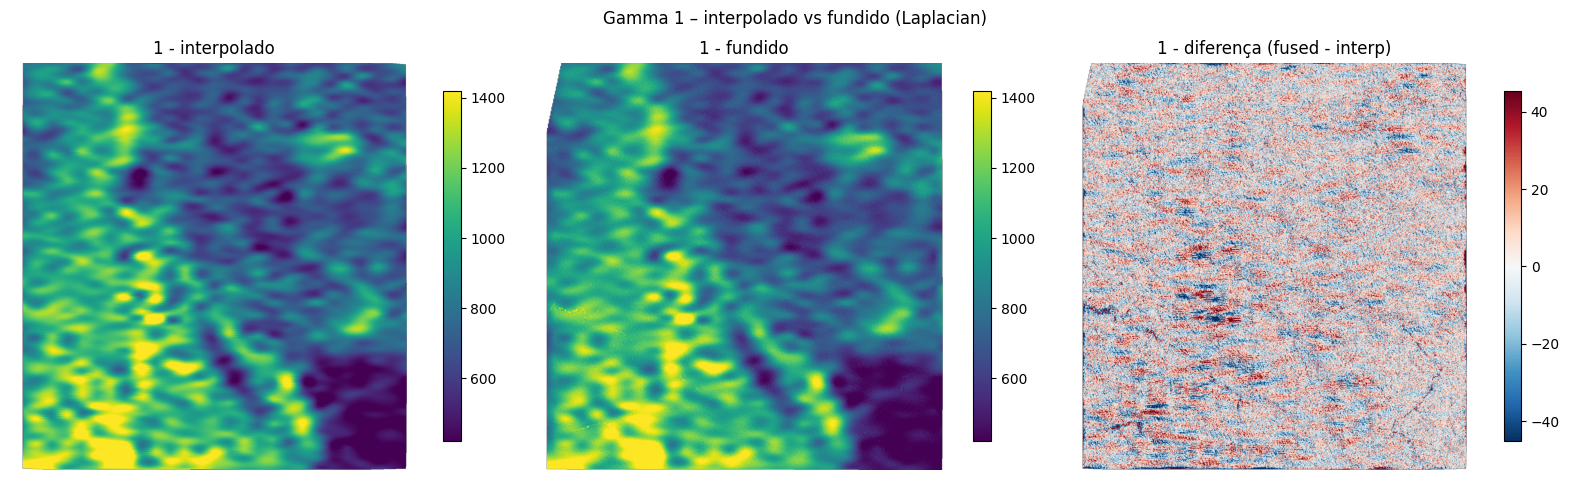

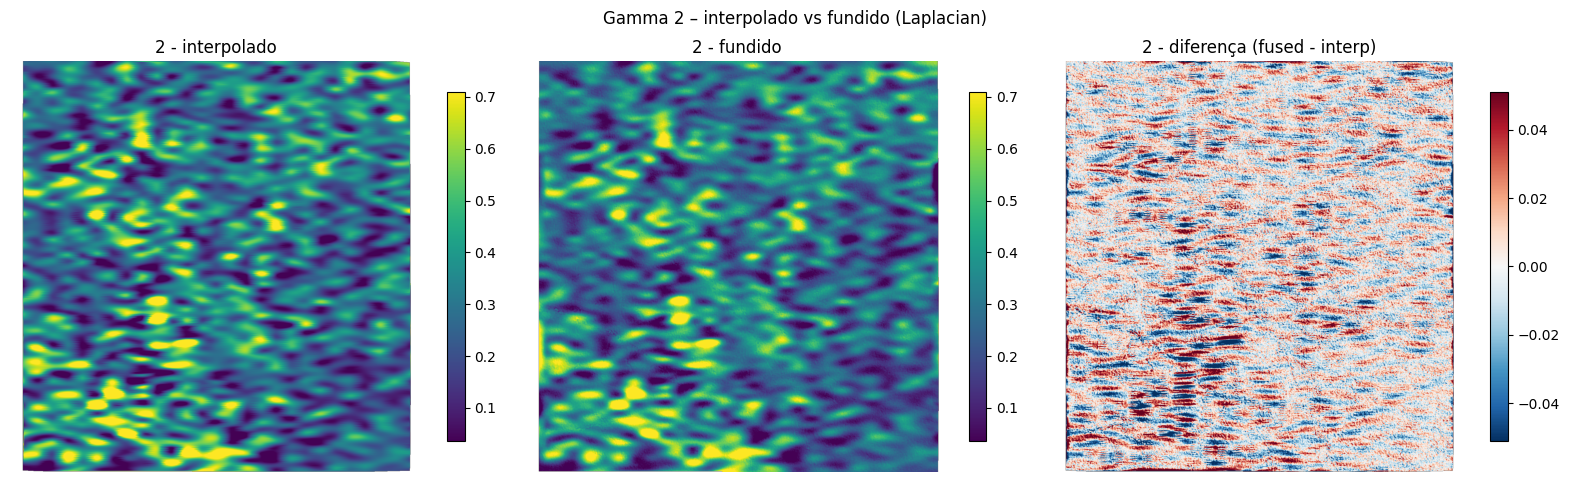

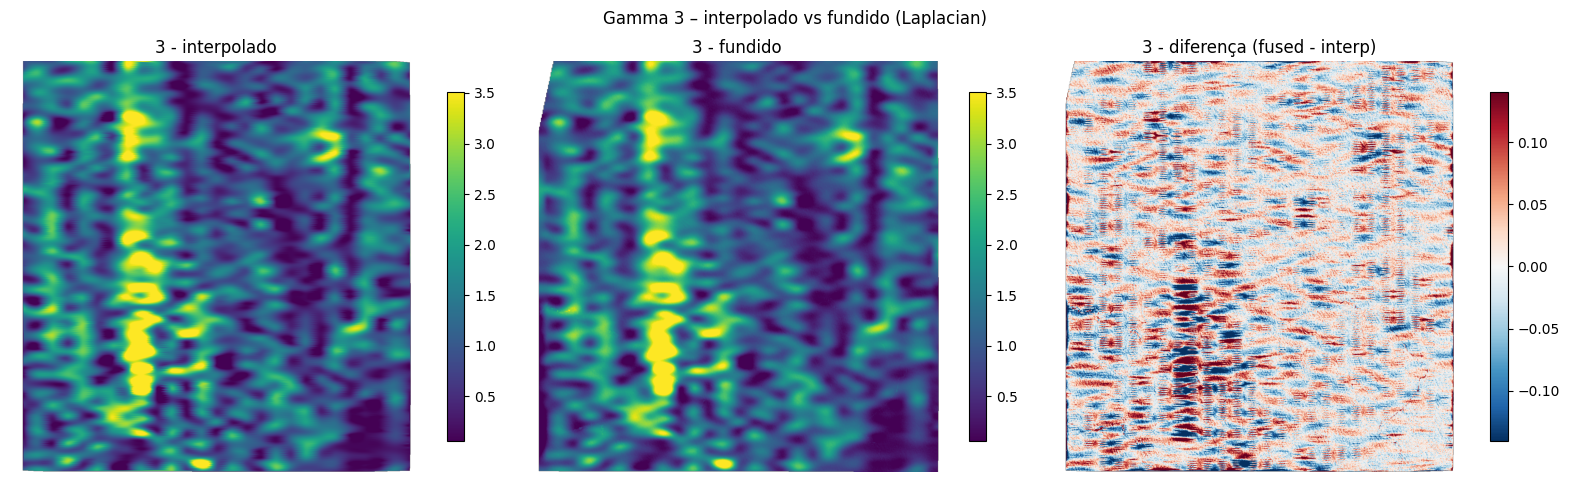

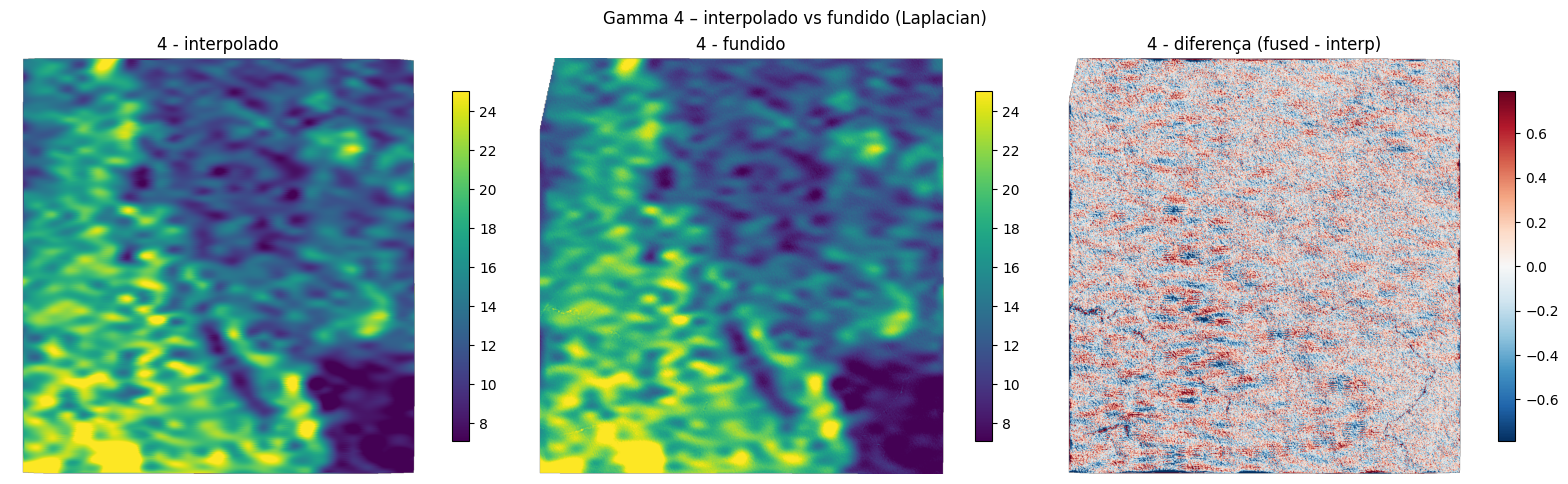


[SUPER] Montando super-cubo MS + gamma_fused...
[SUPER] Super-cubo final shape = (23, 1384, 1385)
[SUPER] Bandas = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'g_1', 'g_2', 'g_3', 'g_4']

[OUTPUT] Salvando super-cubo MS+gamma_fused em: ./recortes_orbitais/SB21_ZA_II2_NW_SUPER_MS_GAMMAF_10m.tif
[CHECK GAMMA FUSION] Concluído.


In [2]:
#!/usr/bin/env python
from __future__ import annotations

import os
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt

RASTER_DIR = "./recortes_orbitais"
FOLHA_CODIGO = "SB21_ZA_II2_NW"

S2_ID    = "S2B_MSIL2A_20230703T140709_R110_T21MWP_20241013T181213"
ASTER_ID = "AST_L1T_00307292004141220_20150505110335"

# Nomes de arquivos
S2_STACK_PATH = os.path.join(
    RASTER_DIR,
    f"{FOLHA_CODIGO}_S2_{S2_ID}_stack.tif",
)
ASTER_GS_PATH = os.path.join(
    RASTER_DIR,
    f"{FOLHA_CODIGO}_ASTER_{ASTER_ID}_VNIR_SWIR_GS_10m.tif",
)
GAMMA_INTERP_PATH = os.path.join(
    RASTER_DIR,
    f"{FOLHA_CODIGO}_gamma_interp_10m.tif",
)
GAMMA_FUSED_PATH = os.path.join(
    RASTER_DIR,
    f"{FOLHA_CODIGO}_gamma_fused_laplacian_10m.tif",
)

# Saída: super-cubo final MS + gamma_fused
SUPER_MS_GAMMA_PATH = os.path.join(
    RASTER_DIR,
    f"{FOLHA_CODIGO}_SUPER_MS_GAMMAF_10m.tif",
)


def load_supercube_ms() -> xr.DataArray:
    """Reabre S2_stack + ASTER_GS e concatena."""
    print(f"[LOAD] Lendo S2_stack: {S2_STACK_PATH}")
    s2_stack = rioxarray.open_rasterio(S2_STACK_PATH, masked=True).astype("float32")
    print(f"[LOAD] S2_stack shape = {s2_stack.shape}, CRS={s2_stack.rio.crs}")

    print(f"[LOAD] Lendo ASTER_GS: {ASTER_GS_PATH}")
    aster_gs = rioxarray.open_rasterio(ASTER_GS_PATH, masked=True).astype("float32")
    print(f"[LOAD] ASTER_GS shape (antes match) = {aster_gs.shape}, CRS={aster_gs.rio.crs}")

    # Garante que ASTER_GS está na mesma grade que S2_stack
    aster_gs = aster_gs.rio.reproject_match(s2_stack)
    print(f"[LOAD] ASTER_GS shape (após match)  = {aster_gs.shape}, CRS={aster_gs.rio.crs}")

    s2_names    = [str(b) for b in s2_stack.band.values]
    aster_names = [str(b) for b in aster_gs.band.values]
    super_names = s2_names + aster_names

    super_cube = xr.concat([s2_stack, aster_gs], dim="band")
    super_cube = super_cube.assign_coords(band=("band", super_names))

    super_cube.rio.write_crs(s2_stack.rio.crs, inplace=True)
    super_cube.rio.write_transform(s2_stack.rio.transform(), inplace=True)

    print(f"[LOAD] Super-cubo MS shape = {super_cube.shape}")
    return super_cube


def check_alignment(ms_da: xr.DataArray, gamma_interp: xr.DataArray, gamma_fused: xr.DataArray):
    """Verifica alinhamento (CRS, transform, shape) entre MS e gammas."""
    print("\n[CHECK] Alinhamento MS vs gamma_interp / gamma_fused")
    print(f"  MS      shape={ms_da.shape}, CRS={ms_da.rio.crs}")
    print(f"  g_interp shape={gamma_interp.shape}, CRS={gamma_interp.rio.crs}")
    print(f"  g_fused  shape={gamma_fused.shape}, CRS={gamma_fused.rio.crs}")

    # Caso algo esteja levemente diferente, faz match explícito
    if gamma_interp.rio.crs != ms_da.rio.crs or gamma_interp.rio.transform() != ms_da.rio.transform():
        print("[CHECK] Reprojetando gamma_interp para grade MS...")
        gamma_interp = gamma_interp.rio.reproject_match(ms_da)

    if gamma_fused.rio.crs != ms_da.rio.crs or gamma_fused.rio.transform() != ms_da.rio.transform():
        print("[CHECK] Reprojetando gamma_fused para grade MS...")
        gamma_fused = gamma_fused.rio.reproject_match(ms_da)

    # Garante shapes idênticos após match
    print(f"[CHECK] Pós-match: g_interp.shape={gamma_interp.shape}, g_fused.shape={gamma_fused.shape}")
    return gamma_interp, gamma_fused


def summarize_gamma(g_interp: xr.DataArray, g_fused: xr.DataArray):
    """Resumo estatístico e métricas de diferença por banda."""
    print("\n[STATS] Comparação banda a banda (gamma_interp vs gamma_fused)")
    for j, name in enumerate(g_interp.band.values):
        arr_i = g_interp.isel(band=j).values
        arr_f = g_fused.isel(band=j).values

        mask = np.isfinite(arr_i) & np.isfinite(arr_f)
        if mask.sum() == 0:
            print(f"  {name}: sem pixels válidos")
            continue

        ai = arr_i[mask]
        af = arr_f[mask]
        diff = af - ai

        mean_i = ai.mean()
        mean_f = af.mean()
        rmse  = np.sqrt(((diff) ** 2).mean())
        corr  = np.corrcoef(ai, af)[0, 1]

        print(
            f"  {name}: "
            f"mean_interp={mean_i:.4f}, "
            f"mean_fused={mean_f:.4f}, "
            f"RMSE={rmse:.4f}, "
            f"corr={corr:.4f}, "
            f"N={mask.sum()}"
        )


def quicklook_gamma_maps(g_interp: xr.DataArray, g_fused: xr.DataArray, max_plots: int = 4):
    """
    Quicklook: mapa de interpolado, fundido e diferença para algumas bandas.
    """
    n_bands = g_interp.sizes["band"]
    n_plot  = min(n_bands, max_plots)

    names = [str(b) for b in g_interp.band.values]

    for j in range(n_plot):
        name = names[j]
        arr_i = g_interp.isel(band=j).values
        arr_f = g_fused.isel(band=j).values
        diff  = arr_f - arr_i

        vmin = np.nanpercentile(arr_i, 2)
        vmax = np.nanpercentile(arr_i, 98)

        dmin = np.nanpercentile(diff, 2)
        dmax = np.nanpercentile(diff, 98)
        dscale = max(abs(dmin), abs(dmax))

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        im1 = axes[0].imshow(arr_i, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[0].set_title(f"{name} - interpolado")
        plt.colorbar(im1, ax=axes[0], shrink=0.8)

        im2 = axes[1].imshow(arr_f, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[1].set_title(f"{name} - fundido")
        plt.colorbar(im2, ax=axes[1], shrink=0.8)

        im3 = axes[2].imshow(diff, cmap="RdBu_r", vmin=-dscale, vmax=dscale)
        axes[2].set_title(f"{name} - diferença (fused - interp)")
        plt.colorbar(im3, ax=axes[2], shrink=0.8)

        for ax in axes:
            ax.axis("off")

        plt.suptitle(f"Gamma {name} – interpolado vs fundido (Laplacian)")
        plt.tight_layout()
        plt.show()


def build_supercube_with_gamma(ms_da: xr.DataArray, gamma_fused: xr.DataArray) -> xr.DataArray:
    """
    Concatena MS (S2+ASTER_GS) com gamma_fused ao longo de 'band'.
    Retorna um DataArray (band, y, x) pronto para gerar patches/pixels na CNN.
    """
    print("\n[SUPER] Montando super-cubo MS + gamma_fused...")

    ms_names   = [str(b) for b in ms_da.band.values]
    gamma_names = [f"g_{str(b)}" for b in gamma_fused.band.values]  # prefixo para evitar conflito
    all_names   = ms_names + gamma_names

    # Concatena ao longo de 'band'
    super_all = xr.concat([ms_da, gamma_fused], dim="band")
    super_all = super_all.assign_coords(band=("band", all_names))

    super_all.rio.write_crs(ms_da.rio.crs, inplace=True)
    super_all.rio.write_transform(ms_da.rio.transform(), inplace=True)

    print(f"[SUPER] Super-cubo final shape = {super_all.shape}")
    print(f"[SUPER] Bandas = {all_names}")

    return super_all


def main():
    print("=" * 80)
    print(f"[CHECK GAMMA FUSION] Folha alvo: {FOLHA_CODIGO}")
    print("=" * 80)

    # 1) MS (S2 + ASTER_GS)
    ms_da = load_supercube_ms()

    # 2) Gamma interpolado e fundido
    print(f"\n[LOAD] Lendo gamma_interp: {GAMMA_INTERP_PATH}")
    gamma_interp = rioxarray.open_rasterio(GAMMA_INTERP_PATH, masked=True).astype("float32")
    print(f"[LOAD] gamma_interp shape = {gamma_interp.shape}, bands={list(gamma_interp.band.values)}")

    print(f"[LOAD] Lendo gamma_fused:  {GAMMA_FUSED_PATH}")
    gamma_fused = rioxarray.open_rasterio(GAMMA_FUSED_PATH, masked=True).astype("float32")
    print(f"[LOAD] gamma_fused shape  = {gamma_fused.shape}, bands={list(gamma_fused.band.values)}")

    # 3) Checar alinhamento
    gamma_interp, gamma_fused = check_alignment(ms_da, gamma_interp, gamma_fused)

    # 4) Estatística global (RMSE, correlação)
    summarize_gamma(gamma_interp, gamma_fused)

    # 5) Quicklooks espaciais para algumas bandas
    quicklook_gamma_maps(gamma_interp, gamma_fused, max_plots=4)

    # 6) Montar super-cubo MS + gamma_fused e salvar
    super_all = build_supercube_with_gamma(ms_da, gamma_fused)

    print(f"\n[OUTPUT] Salvando super-cubo MS+gamma_fused em: {SUPER_MS_GAMMA_PATH}")
    super_all.rio.to_raster(SUPER_MS_GAMMA_PATH)
    print("[CHECK GAMMA FUSION] Concluído.")


if __name__ == "__main__":
    main()
